# Configure Aggregate Module Params

This notebook should be used as a test for ensuring correct aggregate parameters before aggregate processing.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for aggregate module

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [11]:
CONFIG_FILE_PATH = "config/config.yml"

In [12]:
from pathlib import Path
from itertools import product
import random

import yaml
import pandas as pd
import matplotlib.pyplot as plt

from lib.shared.file_utils import get_filename, load_parquet_subset
from lib.aggregate.cell_data_utils import split_cell_data, channel_combo_subset
from lib.aggregate.cell_classification import CellClassifier
from lib.aggregate.montage_utils import create_cell_montage, add_filenames
from lib.aggregate.filter import (
    query_filter,
    perturbation_filter,
    missing_values_filter,
    intensity_filter,
)
from lib.aggregate.align import (
    prepare_alignment_data,
    pca_variance_plot,
    embed_by_pca,
    tvn_on_controls,
)
from lib.aggregate.aggregate import aggregate
from lib.aggregate.eval_aggregate import (
    nas_summary,
    summarize_cell_data,
    plot_feature_distributions,
)
from lib.shared.configuration_utils import CONFIG_FILE_HEADER, convert_tuples_to_lists

random.seed(42)

## <font color='red'>SET PARAMETERS</font>

### Testing on subset of data

- `TEST_PLATE`: Plate used for testing configuration 
- `TEST_WELL_1`: First well identifier used for testing configuration
- `TEST_WELL_2`: Second well identifier used for testing configuration

In [13]:
TEST_PLATE = 5
TEST_WELL_1 = "A1"
TEST_WELL_2 = "A2"

In [14]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)
ROOT_FP = Path(config["all"]["root_fp"])

# Load subset of data
# Takes ~1 minute
merge_final_fp = (
    ROOT_FP
    / "merge"
    / "parquets"
    / get_filename({"plate": TEST_PLATE, "well": TEST_WELL_1}, "merge_final", "parquet")
)
cell_data = load_parquet_subset(merge_final_fp, n_rows=25000)

merge_final_fp_2 = (
    ROOT_FP
    / "merge"
    / "parquets"
    / get_filename({"plate": TEST_PLATE, "well": TEST_WELL_2}, "merge_final", "parquet")
)
cell_data_2 = load_parquet_subset(merge_final_fp_2, n_rows=25000)

cell_data = pd.concat([cell_data, cell_data_2], ignore_index=True)
cell_data

Reading first 25,000 rows from brieflow_output/merge/parquets/P-5_W-A1__merge_final.parquet
Reading first 25,000 rows from brieflow_output/merge/parquets/P-5_W-A2__merge_final.parquet


,plate,well,tile,cell_0,i_0,j_0,site,cell_1,i_1,j_1,...,cytoplasm_zernike_9_1,cytoplasm_zernike_9_3,cytoplasm_zernike_9_5,cytoplasm_zernike_9_7,cytoplasm_zernike_9_9,cytoplasm_number_neighbors_1,cytoplasm_percent_touching_1,cytoplasm_first_neighbor_distance,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors
0,5,A1,28,629,1480.227935,1445.586118,9,2484,740.530120,740.265060,...,0.029744,0.036289,0.020380,0.034216,0.024887,4,0.450593,64.736370,79.126034,101.647618
1,5,A1,1,772,1482.755912,1440.067887,1,3073,739.301075,740.311828,...,0.076526,0.155802,0.028025,0.042346,0.002259,5,0.672489,61.625475,63.763186,116.737810
2,5,A1,742,698,1425.349760,1496.506502,177,2670,741.061856,740.226804,...,0.068911,0.079944,0.037023,0.034038,0.026429,3,0.480144,50.757258,63.291238,140.983634
3,5,A1,811,569,1449.064202,1506.068742,212,2206,741.484848,740.777778,...,0.016350,0.014636,0.062757,0.053132,0.036015,3,0.354478,52.892497,75.694624,50.684425
4,5,A1,718,620,1474.081620,1491.950514,189,2246,741.421053,739.042105,...,0.060837,0.070748,0.087767,0.042576,0.034157,3,0.406780,51.456188,80.022329,140.135770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,A2,1027,631,1525.255522,2021.320783,265,2408,757.750000,864.424242,...,0.297909,0.218439,0.009946,0.061558,0.017316,3,0.470476,54.623254,66.610833,100.202291
49996,5,A2,251,659,1578.209040,994.528955,68,2493,769.511364,617.829545,...,0.048725,0.048841,0.041786,0.049569,0.015170,5,0.457686,74.463835,77.458672,128.632568
49997,5,A2,465,473,1177.487151,1896.495531,118,2204,664.752066,840.669421,...,0.079564,0.058850,0.022223,0.040007,0.037387,5,0.578662,68.777006,70.878411,86.174966
49998,5,A2,1041,933,1773.118792,1889.355705,258,3432,826.687500,831.010417,...,0.061921,0.022387,0.120252,0.068418,0.080429,5,0.637201,55.142845,60.551121,152.430044


In [15]:
for col in cell_data.columns:
    print(col)

plate
well
tile
cell_0
i_0
j_0
site
cell_1
i_1
j_1
distance
fov_distance_0
fov_distance_1
cell_barcode_0
gene_symbol_0
cell_barcode_1
gene_symbol_1
mapped_single_gene
channels_min
nucleus_i
nucleus_j
nucleus_bounds_0
nucleus_bounds_1
nucleus_bounds_2
nucleus_bounds_3
cell_i
cell_j
cell_bounds_0
cell_bounds_1
cell_bounds_2
cell_bounds_3
cytoplasm_i
cytoplasm_j
cytoplasm_bounds_0
cytoplasm_bounds_1
cytoplasm_bounds_2
cytoplasm_bounds_3
nucleus_DAPI_int
nucleus_TUBULIN_int
nucleus_GH2AX_int
nucleus_PHALLOIDIN_int
nucleus_DAPI_mean
nucleus_TUBULIN_mean
nucleus_GH2AX_mean
nucleus_PHALLOIDIN_mean
nucleus_DAPI_std
nucleus_TUBULIN_std
nucleus_GH2AX_std
nucleus_PHALLOIDIN_std
nucleus_DAPI_max
nucleus_TUBULIN_max
nucleus_GH2AX_max
nucleus_PHALLOIDIN_max
nucleus_DAPI_min
nucleus_TUBULIN_min
nucleus_GH2AX_min
nucleus_PHALLOIDIN_min
nucleus_DAPI_int_edge
nucleus_TUBULIN_int_edge
nucleus_GH2AX_int_edge
nucleus_PHALLOIDIN_int_edge
nucleus_DAPI_mean_edge
nucleus_TUBULIN_mean_edge
nucleus_GH2AX_mean_ed

## <font color='red'>SET PARAMETERS</font>

### Cell Data Metadata

- `METADATA_COLS_FP`: Path to TSV to store metadata cols.
- `METADATA_COLS`: Loaded from config (set in notebook 7). Modify if needed.

In [16]:
# Load classification settings from config (set in notebook 7)
from lib.phenotype.constants import DEFAULT_METADATA_COLS

if "classify" in config:
    METADATA_COLS_FP = config["classify"]["metadata_cols_fp"]
    CLASSIFIER_PATH = config["classify"]["classifier_path"]
    CONFIDENCE_THRESHOLDS = config["classify"]["confidence_thresholds"]
    CLASS_TITLE = config["classify"]["class_title"]  # e.g., "cell_stage"
    CLASS_MAPPING = config["classify"]["class_mapping"]  # e.g., {"label_to_class": {1: "Mitotic", 2: "Interphase"}}
    # Load metadata columns from file
    METADATA_COLS = pd.read_csv(METADATA_COLS_FP, header=None, sep="\t")[0].tolist()
    print(f"Loaded metadata columns from classify config: {METADATA_COLS_FP}")
else:
    # Fall back to defaults if classify notebook was skipped
    METADATA_COLS_FP = "config/cell_data_metadata_cols.tsv"
    CLASSIFIER_PATH = None
    CONFIDENCE_THRESHOLDS = None
    CLASS_TITLE = None
    CLASS_MAPPING = None
    METADATA_COLS = DEFAULT_METADATA_COLS.copy()
    # Save default metadata cols to file for pipeline
    pd.Series(METADATA_COLS).to_csv(METADATA_COLS_FP, index=False, header=False, sep="\t")
    print(f"Using DEFAULT_METADATA_COLS (classify notebook was skipped)")
    print(f"Saved to: {METADATA_COLS_FP}")

# Always show the metadata columns so user can verify
print(f"\nClassifier path: {CLASSIFIER_PATH}")
print(f"Class title: {CLASS_TITLE}")
print(f"Class mapping: {CLASS_MAPPING}")
print(f"Confidence thresholds: {CONFIDENCE_THRESHOLDS}")
print(f"\n{len(METADATA_COLS)} metadata columns:")
for col in METADATA_COLS:
    print(f"  - {col}")

Loaded metadata columns from classify config: config/cell_data_metadata_cols.tsv

Classifier path: brieflow_output/classifier/classifier/run_20260112_172222/models/multiclass_xgb_k50/multiclass_xgb_k50_model.dill
Class title: cell_stage
Class mapping: {'label_to_class': {1: 'Mitotic', 2: 'Interphase'}}
Confidence thresholds: {1: {'threshold': 0.80796, 'mode': 'reassign'}, 2: {'threshold': 0.5, 'mode': 'exclude'}}

37 metadata columns:
  - plate
  - well
  - tile
  - cell_0
  - i_0
  - j_0
  - site
  - cell_1
  - i_1
  - j_1
  - distance
  - fov_distance_0
  - fov_distance_1
  - cell_barcode_0
  - gene_symbol_0
  - cell_barcode_1
  - gene_symbol_1
  - mapped_single_gene
  - channels_min
  - nucleus_i
  - nucleus_j
  - nucleus_bounds_0
  - nucleus_bounds_1
  - nucleus_bounds_2
  - nucleus_bounds_3
  - cell_i
  - cell_j
  - cell_bounds_0
  - cell_bounds_1
  - cell_bounds_2
  - cell_bounds_3
  - cytoplasm_i
  - cytoplasm_j
  - cytoplasm_bounds_0
  - cytoplasm_bounds_1
  - cytoplasm_bounds_

In [17]:
# Split cell data into metadata and features
metadata, features = split_cell_data(cell_data, METADATA_COLS)
print(metadata.shape, features.shape)

Validating feature columns ...
All feature columns have valid numeric dtypes
(50000, 37) (50000, 1649)


## <font color='red'>SET PARAMETERS</font>

### Split cells into classes

- `CLASSIFIER_PATH`: Path to pickled Python object that can take a cell data dataframe and output cell classes

### Evaluate splitting

- `COLLAPSE_COLS`: Cell data columns to collapse on when creating a summary of cell counts. This will show the number of cells in each cell class for these particular columns. Ex: `["cell_barcode_0", "gene_symbol_0"]`.
- `MONTAGE_CHANNEL`: Channel to use for montage generation. Usually `DAPI`.

**Notes**: 
- We generate cell classes for each of the classes listed in the classifier and an "all" class. So for a classifier that splits by mitotic or interphase the final classes will be `["mitotic", "interphase", "all"]`.
- You must import necessary packages for the classifier in this notebook and add them to `scripts/aggregate/split_datasets.py` as well. Ex `import numpy as np` if the classifier requires `numpy`.

In [21]:
# Classification settings loaded from config above
# Override here if needed:
# CLASSIFIER_PATH = None
# CONFIDENCE_THRESHOLD = None

MONTAGE_CHANNEL = "DAPI"
COLLAPSE_COLS = ["cell_barcode_0", "gene_symbol_0"]

Applying cell classification...
Removing 7 rows with NaN values in features

Cell class counts:
class
Interphase    48494
Mitotic        1499
Name: count, dtype: int64

Cell class confidences:


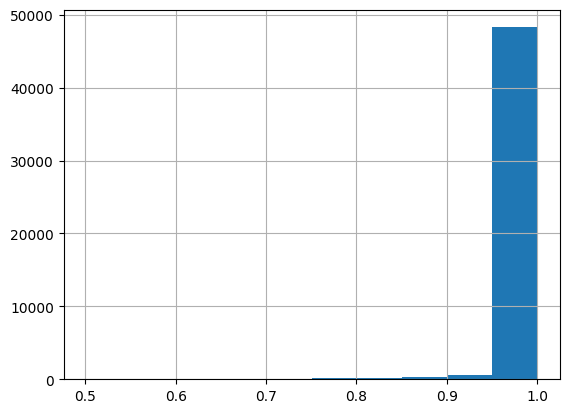

In [22]:
classifier = CellClassifier.load(CLASSIFIER_PATH)

# Classify cells with safety check
if classifier is not None:
    print("Applying cell classification...")
    classified_metadata, classified_features = classifier.classify_cells(metadata, features)
    
    # Add standard 'class' and 'confidence' columns using the mapping
    confidence_col = f"{CLASS_TITLE}_confidence"
    if CLASS_MAPPING and "label_to_class" in CLASS_MAPPING:
        label_to_class = CLASS_MAPPING["label_to_class"]
        # Convert numeric IDs to string labels
        classified_metadata["class"] = classified_metadata[CLASS_TITLE].map(
            lambda x: label_to_class.get(x, label_to_class.get(str(x), str(x)))
        )
    else:
        # No mapping available, use numeric values as strings
        classified_metadata["class"] = classified_metadata[CLASS_TITLE].astype(str)
    
    # Add standard confidence column
    classified_metadata["confidence"] = classified_metadata[confidence_col]
else:
    print("No classifier specified - using all cells as single class")
    classified_metadata, classified_features = metadata, features

# Create config var for cell classes
if "class" in classified_metadata.columns:
    CELL_CLASSES = list(classified_metadata["class"].unique())
else:
    CELL_CLASSES = []

# Show cell class counts and distribution
if CELL_CLASSES:
    print("\nCell class counts:")
    print(classified_metadata["class"].value_counts())

    print("\nCell class confidences:")
    classified_metadata["confidence"].hist()
else:
    print("No cell classes available")

Montages of cell classes:


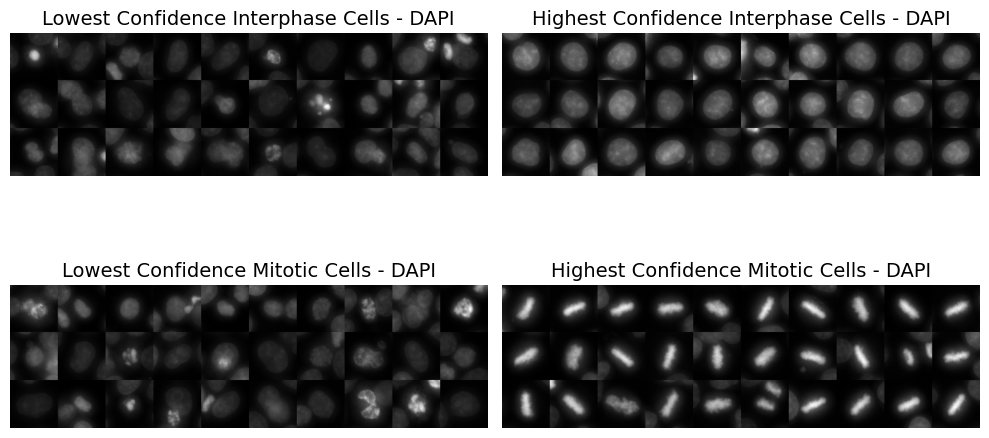

Split cell data summary:


,Stage,Count,Percent
0,Raw Data,49993,100.00
1,Interphase cells,48494,97.00
2,Interphase cell_barcode_0,11834,23.67
3,Interphase gene_symbol_0,5055,10.11
4,Mitotic cells,1499,3.00
5,Mitotic cell_barcode_0,1253,2.51
6,Mitotic gene_symbol_0,1144,2.29


In [23]:
cell_classes = list(classified_metadata["class"].unique()) + ["all"]

classified_metadata_copy = classified_metadata.copy(deep=True)
classified_metadata_copy = add_filenames(classified_metadata_copy, ROOT_FP)

# Create a dictionary of DataFrames for each cell class
cell_class_dfs = {
    cell_class: classified_metadata_copy[
        classified_metadata_copy["class"] == cell_class
    ]
    for cell_class in CELL_CLASSES
}

# Define sorting directions and titles
title_templates = {
    True: "Lowest Confidence {cell_class} Cells - {channel}",
    False: "Highest Confidence {cell_class} Cells - {channel}",
}

# Generate montages dynamically
montages, titles = [], []
for cell_class, cell_df in cell_class_dfs.items():
    for ascending in [True, False]:
        montage = create_cell_montage(
            cell_data=cell_df,
            channels=config["phenotype"]["channel_names"],
            selection_params={
                "method": "sorted",
                "sort_by": "confidence",
                "ascending": ascending,
            },
        )[MONTAGE_CHANNEL]
        montages.append(montage)
        titles.append(
            title_templates[ascending].format(
                cell_class=cell_class, channel=MONTAGE_CHANNEL
            )
        )

# Determine figure size dynamically
num_rows = len(CELL_CLASSES)
fig, axes = plt.subplots(num_rows, 2, figsize=(10, 3 * num_rows))

# Display montages
for ax, title, montage in zip(axes.flat, titles, montages):
    ax.imshow(montage, cmap="gray")
    ax.set_title(title, fontsize=14)
    ax.axis("off")

print("Montages of cell classes:")
plt.tight_layout()
plt.show()

print("Split cell data summary:")
summary_df = summarize_cell_data(classified_metadata, CELL_CLASSES, COLLAPSE_COLS)
display(summary_df)

## <font color='red'>SET PARAMETERS</font>

### Aggregate by channel combos

- `CHANNEL_COMBOS`: Combinations of channels to aggregate by. This is a list of lists with channel names, ex `[["DAPI", "CENPA"], ["DAPI", "WGA"]]`.
- `AGGREGATE_COMBO_FP`: Location of aggregate combinations dataframe.
- `TEST_CELL_CLASS`: Cell class to configure aggregate params with. Can be any of the cell classes or `all`.
- `TEST_CHANNEL_COMBO`: Channel combo to configure aggregate params with; must be one of the channel combos. Ex `["DAPI", "CENPA"]`.

In [24]:
CHANNEL_COMBOS = [['DAPI','TUBULIN','GH2AX','PHALLOIDIN']]
AGGREGATE_COMBO_FP = "config/aggregate_combo.tsv"

TEST_CELL_CLASS = "all"
TEST_CHANNEL_COMBO = ['DAPI','TUBULIN','GH2AX','PHALLOIDIN']

In [25]:
# determine cell classes and channel combos
channel_combos = ["_".join(combo) for combo in CHANNEL_COMBOS]

# Load merge wildcard combos
MERGE_COMBO_FP = Path(config["merge"]["merge_combo_fp"])
merge_wildcard_combos = pd.read_csv(MERGE_COMBO_FP, sep="\t")

# Generate aggregate wildcard combos
aggregate_wildcard_combos = pd.DataFrame(
    product(
        merge_wildcard_combos.itertuples(index=False, name=None),
        cell_classes,
        channel_combos,
    ),
    columns=["plate_well", "cell_class", "channel_combo"],
)
aggregate_wildcard_combos[["plate", "well"]] = pd.DataFrame(
    aggregate_wildcard_combos["plate_well"].tolist(),
    index=aggregate_wildcard_combos.index,
)
aggregate_wildcard_combos = aggregate_wildcard_combos.drop(columns="plate_well")

# Save aggregate wildcard combos
aggregate_wildcard_combos.to_csv(AGGREGATE_COMBO_FP, sep="\t", index=False)

print("Aggregate wildcard combos:")
aggregate_wildcard_combos

Aggregate wildcard combos:


,cell_class,channel_combo,plate,well
0,Interphase,DAPI_TUBULIN_GH2AX_PHALLOIDIN,7,A2
1,Mitotic,DAPI_TUBULIN_GH2AX_PHALLOIDIN,7,A2
2,all,DAPI_TUBULIN_GH2AX_PHALLOIDIN,7,A2
3,Interphase,DAPI_TUBULIN_GH2AX_PHALLOIDIN,1,B2
4,Mitotic,DAPI_TUBULIN_GH2AX_PHALLOIDIN,1,B2
...,...,...,...,...
130,Mitotic,DAPI_TUBULIN_GH2AX_PHALLOIDIN,7,B3
131,all,DAPI_TUBULIN_GH2AX_PHALLOIDIN,7,B3
132,Interphase,DAPI_TUBULIN_GH2AX_PHALLOIDIN,8,B2
133,Mitotic,DAPI_TUBULIN_GH2AX_PHALLOIDIN,8,B2


In [26]:
# subset cell class
if TEST_CELL_CLASS != "all":
    cell_class_mask = classified_metadata["class"] == TEST_CELL_CLASS
    class_metadata = classified_metadata[cell_class_mask]
    class_features = classified_features[cell_class_mask]
else:
    class_metadata = classified_metadata
    class_features = classified_features

# subset features
all_channels = config["phenotype"]["channel_names"]
class_features = channel_combo_subset(class_features, TEST_CHANNEL_COMBO, all_channels)

# copy metadata and features for later eval
dataset_metadata = class_metadata.copy()
dataset_features = class_features.copy()

# preview metadata and features
display(class_metadata)
display(class_features)

,plate,well,tile,cell_0,i_0,j_0,site,cell_1,i_1,j_1,...,cytoplasm_i,cytoplasm_j,cytoplasm_bounds_0,cytoplasm_bounds_1,cytoplasm_bounds_2,cytoplasm_bounds_3,cell_stage,cell_stage_confidence,class,confidence
0,5,A1,28,629,1480.227935,1445.586118,9,2484,740.530120,740.265060,...,1494.683779,1431.601584,1447,1395,1536,1476,2,0.999425,Interphase,0.999425
1,5,A1,1,772,1482.755912,1440.067887,1,3073,739.301075,740.311828,...,1467.163743,1444.419799,1425,1412,1523,1480,2,0.993067,Interphase,0.993067
2,5,A1,742,698,1425.349760,1496.506502,177,2670,741.061856,740.226804,...,1419.669809,1505.240943,1382,1448,1467,1552,2,0.998299,Interphase,0.998299
3,5,A1,811,569,1449.064202,1506.068742,212,2206,741.484848,740.777778,...,1450.448032,1496.145449,1419,1438,1480,1556,2,0.998258,Interphase,0.998258
4,5,A1,718,620,1474.081620,1491.950514,189,2246,741.421053,739.042105,...,1473.031227,1477.013879,1441,1429,1508,1536,2,0.999935,Interphase,0.999935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,5,A2,1027,631,1525.255522,2021.320783,265,2408,757.750000,864.424242,...,1527.472278,2012.425907,1488,1969,1559,2058,2,0.999594,Interphase,0.999594
49996,5,A2,251,659,1578.209040,994.528955,68,2493,769.511364,617.829545,...,1582.753696,1004.696023,1537,944,1625,1056,2,0.999714,Interphase,0.999714
49997,5,A2,465,473,1177.487151,1896.495531,118,2204,664.752066,840.669421,...,1167.420723,1886.108454,1125,1841,1217,1930,2,0.999845,Interphase,0.999845
49998,5,A2,1041,933,1773.118792,1889.355705,258,3432,826.687500,831.010417,...,1786.390219,1887.996185,1736,1853,1836,1933,2,0.999772,Interphase,0.999772


,nucleus_DAPI_int,nucleus_TUBULIN_int,nucleus_GH2AX_int,nucleus_PHALLOIDIN_int,nucleus_DAPI_mean,nucleus_TUBULIN_mean,nucleus_GH2AX_mean,nucleus_PHALLOIDIN_mean,nucleus_DAPI_std,nucleus_TUBULIN_std,...,cytoplasm_zernike_9_1,cytoplasm_zernike_9_3,cytoplasm_zernike_9_5,cytoplasm_zernike_9_7,cytoplasm_zernike_9_9,cytoplasm_number_neighbors_1,cytoplasm_percent_touching_1,cytoplasm_first_neighbor_distance,cytoplasm_second_neighbor_distance,cytoplasm_angle_between_neighbors
0,4472452,3726287,1003789,1041335,3832.435304,3193.047986,860.144816,892.317909,583.719860,291.763608,...,0.029744,0.036289,0.020380,0.034216,0.024887,4,0.450593,64.736370,79.126034,101.647618
1,4639362,4387069,3059394,1344837,3538.796339,3346.353166,2333.633867,1025.810069,565.346915,183.305345,...,0.076526,0.155802,0.028025,0.042346,0.002259,5,0.672489,61.625475,63.763186,116.737810
2,4746975,4590286,1161042,1054246,3249.127310,3141.879535,794.689938,721.592060,500.721102,112.947102,...,0.068911,0.079944,0.037023,0.034038,0.026429,3,0.480144,50.757258,63.291238,140.983634
3,6637440,4759114,1920327,1031463,4304.435798,3086.325551,1245.348249,668.912451,810.020410,209.187482,...,0.016350,0.014636,0.062757,0.053132,0.036015,3,0.354478,52.892497,75.694624,50.684425
4,5132329,4502298,1265414,949545,3298.411954,2893.507712,813.248072,610.247429,544.199356,211.754667,...,0.060837,0.070748,0.087767,0.042576,0.034157,3,0.406780,51.456188,80.022329,140.135770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,9312408,6940131,2397245,1510146,4674.903614,3484.001506,1203.436245,758.105422,883.184262,221.305463,...,0.297909,0.218439,0.009946,0.061558,0.017316,3,0.470476,54.623254,66.610833,100.202291
49996,4657071,4327000,1118912,946936,3288.891949,3055.790960,790.192090,668.740113,533.123999,124.427247,...,0.048725,0.048841,0.041786,0.049569,0.015170,5,0.457686,74.463835,77.458672,128.632568
49997,8949318,6131703,4124536,1475262,4999.618994,3425.532402,2304.210056,824.168715,949.905323,223.084844,...,0.079564,0.058850,0.022223,0.040007,0.037387,5,0.578662,68.777006,70.878411,86.174966
49998,4807320,4031855,1125565,960582,3226.389262,2705.942953,755.412752,644.685906,616.604168,156.330789,...,0.061921,0.022387,0.120252,0.068418,0.080429,5,0.637201,55.142845,60.551121,152.430044


## <font color='red'>SET PARAMETERS</font>

### Perturbation filtering

- `FILTER_QUERIES`: Queries to use for custom filtering; ex: `["mapped_single_gene == True", "cell_quality_score > 0.8"]`. Can be left as `None` for no filtering.
- `PERTURBATION_NAME_COL`: Name of column used to identify perturbations. This is the column that aggregation takes place on. Ex "gene_symbol_0".

In [33]:
FILTER_QUERIES = ["mapped_single_gene == True"]
PERTURBATION_NAME_COL = "gene_symbol_0"

Query 'mapped_single_gene == True' filtered out 0 cells
Found 49993 cells with assigned perturbations
Unique populations: 5067
                              column  percent_na
0         cytoplasm_DAPI_mean_frac_0    0.731482
1      cytoplasm_TUBULIN_mean_frac_0    0.731482
2        cytoplasm_GH2AX_mean_frac_0    0.731482
3   cytoplasm_PHALLOIDIN_mean_frac_0    0.731482
8         cytoplasm_DAPI_radial_cv_0    0.731482
9      cytoplasm_TUBULIN_radial_cv_0    0.731482
10       cytoplasm_GH2AX_radial_cv_0    0.731482
11  cytoplasm_PHALLOIDIN_radial_cv_0    0.731482


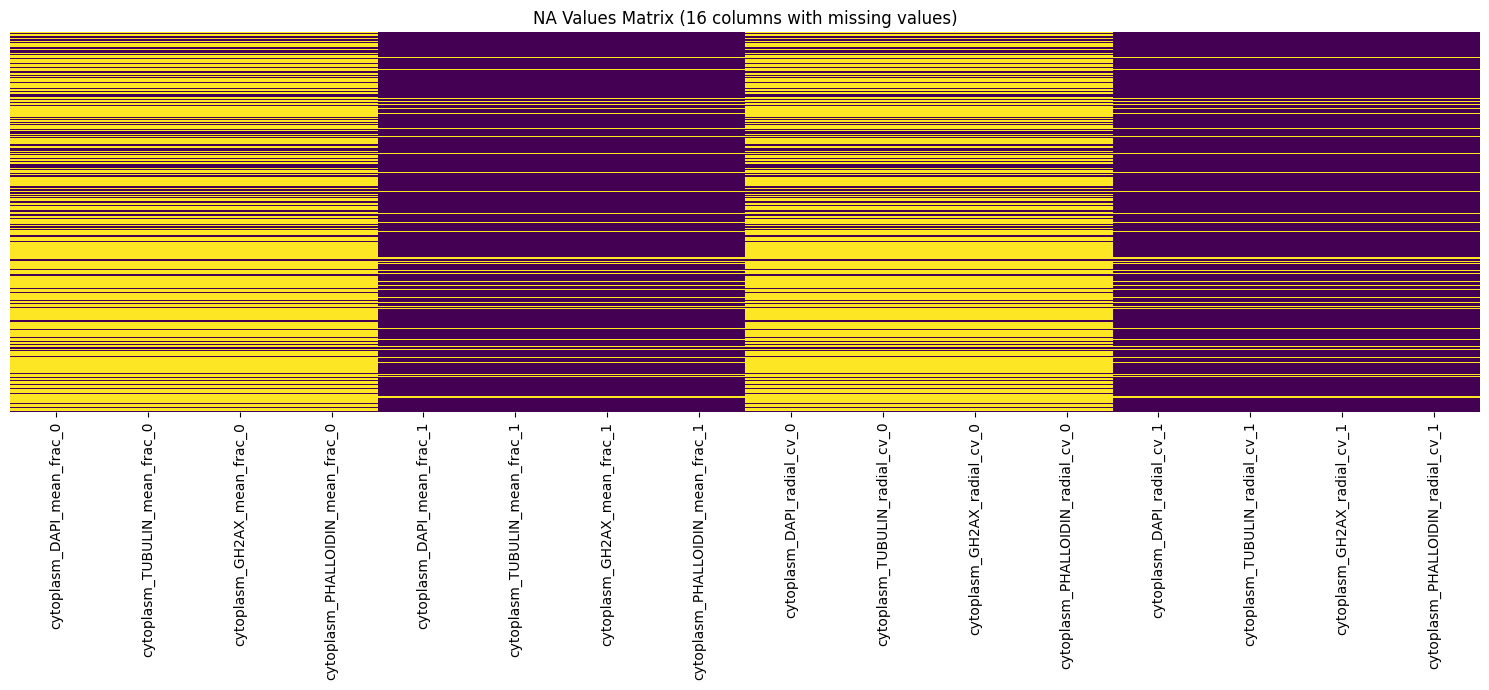

In [34]:
qf_metadata, qf_features = query_filter(class_metadata, class_features, FILTER_QUERIES)

pf_metadata, pf_features = perturbation_filter(
    qf_metadata, qf_features, PERTURBATION_NAME_COL
)
print(f"Unique populations: {metadata[PERTURBATION_NAME_COL].nunique()}")

summary_df, fig = nas_summary(pf_features)
print(summary_df[summary_df["percent_na"] > 0.1])
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Missing value filtering

- `DROP_COLS_THRESHOLD`: Threshold of NA values above which an entire column is dropped. Usually `0.1`
- `DROP_ROWS_THRESHOLD`: Threshold of NA values above which an entire row is dropped. Usually `0.01`
- `IMPUTE`: Whether or not to impute remaining missing values. Usually `True`

**Note**: All NAs must be dropped or imputed to perform feature alignment.

In [35]:
DROP_COLS_THRESHOLD = 0.05
DROP_ROWS_THRESHOLD = 0.01
IMPUTE = True

In [36]:
# Filter by missing values
mvf_metadata, mvf_features = missing_values_filter(
    pf_metadata,
    pf_features,
    drop_cols_threshold=DROP_COLS_THRESHOLD,
    drop_rows_threshold=DROP_ROWS_THRESHOLD,
    impute=True,
)

mvf_metadata.shape, mvf_features.shape

Dropping 16 columns with ≥5.0% missing values
Dropped 0 rows with ≥1.0% missing values


((49993, 41), (49993, 1633))

## <font color='red'>SET PARAMETERS</font>

### Intensity filtering

- `CONTAMINATION`: Expected proportion of outliers in dataset. Usually `0.01`

In [37]:
CONTAMINATION = 0.01

In [38]:
# Filter by intensity outliers
if_metadata, if_features = intensity_filter(
    mvf_metadata,
    mvf_features,
    config["phenotype"]["channel_names"],
    CONTAMINATION,
)

if_metadata.shape, if_features.shape

((49493, 41), (49493, 1633))

## <font color='red'>SET PARAMETERS</font>

### Perturbation Score Filtering

One can optionally assigned perturbation scores to each cell with perturbation scoring and filtering. During scoring, we train a Logistic Regression classifier on perturbed and control cell features. The result of this training and classification process is:
- `AUC Score` assinged per perturbation: this represents the classifier's ability to distinguish between perturbed and control cells -> higher AUC score, more clear effect on perturbation level
- `Perturbation Probability` assigned per cell: this represents the classifier's assigned probability of the cell being perturbed -> higher perturbation probability, more clear effect on cell level

Once perturbation scores are assigned, one can optionally filter with a probability or percentile threshold before aggregation. Control cells will not be filtered.

Configure perturbation score filtering with:
- `SKIP_PERTURBATION_SCORE`: Whether or not to skip perturbation scoring entirely. Usually `False`
- `PS_PROBABILITY_THRESHOLD`: Probability threshold above which to keep perturbed cells. Usually `0.75`
- `PS_PERCENTILE_THRESHOLD`: Percentile threshold above which to keep perturbed cells. Usually `0.75`

Leave `PS_PROBABILITY_THRESHOLD` and `PS_PERCENTILE_THRESHOLD` as `None` if no filtering is desired.

**Notes:** 
- We don't test perturbation scoring within this notebook as it requires sampling many cells with the same perturbation across plates and wells
- Both types of threshold will remove cells, and probability threshold can potentially eliminate all cells in a perturbation
- Perturbation scoring can take hours per dataset

In [39]:
SKIP_PERTURBATION_SCORE = False
PS_PROBABILITY_THRESHOLD = None
PS_PERCENTILE_THRESHOLD = None

## <font color='red'>SET PARAMETERS</font>

### Prepare alignment data

- `BATCH_COLS`: Which columns of metadata have batch-specific information. Usually `["plate", "well"]`.
- `CONTROL_KEY`: Name of perturbation in `PERTURBATION_NAME_COL` that indicates a control cell.
- `PERTURBATION_ID_COL`: Name of column that identifies unique perturbations. Only needed if you want your controls to have different perturbation names, ex `cell_barcode_0`. Otherwise, can leave this as `None`.

In [40]:
BATCH_COLS = ["plate", "well"]
CONTROL_KEY = "nontargeting"
PERTURBATION_ID_COL = "cell_barcode_0"

In [ ]:
pad_metadata, pad_features = prepare_alignment_data(
    if_metadata,
    if_features,
    BATCH_COLS,
    PERTURBATION_NAME_COL,
    CONTROL_KEY,
    PERTURBATION_ID_COL,
)

n_components, fig = pca_variance_plot(pad_features, variance_threshold=0.99)
plt.show()

## <font color='red'>SET PARAMETERS</font>

### Align and aggregate

- `VARIANCE_OR_NCOMP`: Variance or number of components to keep after PCA.
- `NUM_ALIGN_BATCHES`: Number of batches to use when aligning, usually `1`. Increase this if you are running out of memory while aligning. We were able to barely fit 8 plates with 6 wells each in 1 TB of memory with `NUM_ALIGN_BATCHES=1`.
- `AGG_METHOD`: Method used to aggregate features. Can be `mean` or `median`. Usually `median`.

While we use a simplified aggregate method in the notebook, the way this works during a normal run is:
1) Take a subset of 1,000,000 cells, or the entire dataset, whichever is smaller and compute a PCA transform with `VARIANCE_OR_NCOMP`.
2) Subset the entire dataset `NUM_BATCHES` number of times and align cells in this batch.
3) Aggregate across all aligned cell data.

In [ ]:
VARIANCE_OR_NCOMP = 0.99
NUM_ALIGN_BATCHES = 1
AGG_METHOD = "median"

In [ ]:
pca_embeddings = embed_by_pca(
    pad_features,
    pad_metadata,
    variance_or_ncomp=VARIANCE_OR_NCOMP,
    batch_col="batch_values",
)

tvn_normalized = tvn_on_controls(
    pca_embeddings, pad_metadata, PERTURBATION_NAME_COL, CONTROL_KEY, "batch_values"
)

aggregated_embeddings, aggregated_metadata = aggregate(
    tvn_normalized, pad_metadata, PERTURBATION_NAME_COL, AGG_METHOD
)

feature_columns = [f"PC_{i}" for i in range(tvn_normalized.shape[1])]

tvn_normalized_df = pd.DataFrame(
    tvn_normalized, index=pad_metadata.index, columns=feature_columns
)
aligned_cell_data = pd.concat([pad_metadata, tvn_normalized_df], axis=1)

aggregated_embeddings_df = pd.DataFrame(
    aggregated_embeddings, index=aggregated_metadata.index, columns=feature_columns
)
aggregated_cell_data = (
    pd.concat([aggregated_metadata, aggregated_embeddings_df], axis=1)
    .sort_values("cell_count", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
original_feature_cols = [
    col
    for col in dataset_features.columns
    if ("cell_" in col and col.endswith("_mean"))
]
pc_cols = [col for col in aggregated_cell_data.columns if col.startswith("PC_")]
aligned_feature_cols = random.sample(
    pc_cols, k=min(len(original_feature_cols), len(pc_cols))
)

original_cell_data = pd.concat([dataset_metadata, dataset_features], axis=1)
original_cell_data

feature_distributions_fig = plot_feature_distributions(
    original_feature_cols,
    original_cell_data,
    aligned_feature_cols,
    aligned_cell_data,
)
plt.show()

## <font color='red'>SET PARAMETERS</font>
### Generate feature table & bootstrapping

Bootstrapping is a statistical resampling method used to determine if perturbations (gene knockdowns, drug treatments, etc.) cause statistically significant changes compared to controls. The method works by:
1. Taking your control population and repeatedly resampling it to create thousands of "null" distributions
2. Comparing each perturbation's effect size against these null distributions
3. Calculating p-values based on how often the null distributions produce effects as large as the real perturbation

- `FEATURE_NORMALIZATION`: Method for normalizing features before bootstrapping. Options: `"standard"` (standard scalar) or `"mad"` (median absolute deviation).
- `NUM_SIMS`: Number of bootstrap simulations to run for statistical testing. Ex: `100000`.
- `EXCLUSION_STRING`: String to exclude certain constructs from analysis (optional). Ex: `"nontargeting_noncutting_"` or `None`.
- `BOOTSTRAP_CELL_CLASS`: Cell class to run bootstrapping on. Ex: `"Interphase"` or `"all"`.
- `BOOTSTRAP_CHANNEL_COMBO`: Channel combination to run bootstrapping on. Ex: `"DAPI_Ki-67_COXIV_Caspase-3_WGA_aTubulin_Vimentin_gH2AX_Phalloidin"`.
- `PSEUDOGENE_PATTERNS`: Dictionary defining how to group single-construct genes into pseudo-genes for more robust statistical testing. For each pattern category, specify:
  - `pattern`: Regex pattern to match gene names
  - `constructs_per_pseudogene`: Number of constructs to group together

**Note**: Without the combinations configured, bootstrapping will be skipped entirely. Bootstrap analysis can take hours to days depending on `NUM_SIMS` and dataset size.

In [ ]:
FEATURE_NORMALIZATION = "mad"
NUM_SIMS = 100000
EXCLUSION_STRING = None
BOOTSTRAP_CELL_CLASS = ["Interphase", "Mitotic"]
BOOTSTRAP_CHANNEL_COMBO = "DAPI_TUBULIN_GH2AX_PHALLOIDIN"
PSEUDOGENE_PATTERNS = None

## Add aggregate parameters to config file

In [ ]:
# Add aggregate section (classifier settings are in config["classify"] from notebook 7)
config["aggregate"] = {
    "metadata_cols_fp": METADATA_COLS_FP,
    "collapse_cols": COLLAPSE_COLS,
    "aggregate_combo_fp": AGGREGATE_COMBO_FP,
    "filter_queries": FILTER_QUERIES,
    "perturbation_name_col": PERTURBATION_NAME_COL,
    "drop_cols_threshold": DROP_COLS_THRESHOLD,
    "drop_rows_threshold": DROP_ROWS_THRESHOLD,
    "impute": IMPUTE,
    "contamination": CONTAMINATION,
    "batch_cols": BATCH_COLS,
    "control_key": CONTROL_KEY,
    "perturbation_id_col": PERTURBATION_ID_COL,
    "variance_or_ncomp": VARIANCE_OR_NCOMP,
    "num_align_batches": NUM_ALIGN_BATCHES,
    "agg_method": AGG_METHOD,
    "skip_perturbation_score": SKIP_PERTURBATION_SCORE,
    "ps_probability_threshold": PS_PROBABILITY_THRESHOLD,
    "ps_percentile_threshold": PS_PERCENTILE_THRESHOLD,
}

if BOOTSTRAP_CELL_CLASS and BOOTSTRAP_CHANNEL_COMBO:
    BOOTSTRAP_COMBINATIONS = [{
        "cell_class": BOOTSTRAP_CELL_CLASS,
        "channel_combo": BOOTSTRAP_CHANNEL_COMBO
    }]
    config["aggregate"].update({
        "feature_normalization": FEATURE_NORMALIZATION,
        "num_sims": NUM_SIMS,
        "exclusion_string": EXCLUSION_STRING,
        "bootstrap_combinations": BOOTSTRAP_COMBINATIONS,
        "pseudogene_patterns": PSEUDOGENE_PATTERNS,
    })

# Convert tuples to lists before dumping
safe_config = convert_tuples_to_lists(config)

# Write the updated configuration
with open(CONFIG_FILE_PATH, "w") as config_file:
    # Write the introductory comments
    config_file.write(CONFIG_FILE_HEADER)

    # Dump the updated YAML structure, keeping markdown comments for sections
    yaml.dump(safe_config, config_file, default_flow_style=False, sort_keys=False)